<a href="https://colab.research.google.com/github/brittanybee-alt/Python-Statistics-in-EDA---Brittany-Barrion-/blob/main/Case_Study_Integrating_Apps_%5BBrittany_Barrion%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import random

Stage 1 - Sourcing and loading data

1a. Source and load the data

In [32]:
google = '/content/googleplaystore.csv'
Google = pd.read_csv(google)
Google.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [33]:
apple = '/content/AppleStore.csv'
Apple = pd.read_csv(apple)
Apple.head()

,Unnamed: 0,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,1,281656475,PAC-MAN Premium,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,1
1,2,281796108,Evernote - stay organized,158578688,USD,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,1
2,3,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,USD,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,1
3,4,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,USD,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,1
4,5,282935706,Bible,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,1


1b. Pick the columns we'll work with

1. Google:

*   Category #Do we need this?
*   Rating
*   Reviews
*   Price (maybe)

2. Apple:

*   prime_genre #Do we need this
*   user_rating
*   rating_count_tot
*   price (maybe)





1c. Subsetting accordingly

In [34]:
Google = Google[['Category', 'Rating', 'Reviews', 'Price']]
Google.head()

,Category,Rating,Reviews,Price
0,ART_AND_DESIGN,4.1,159,0
1,ART_AND_DESIGN,3.9,967,0
2,ART_AND_DESIGN,4.7,87510,0
3,ART_AND_DESIGN,4.5,215644,0
4,ART_AND_DESIGN,4.3,967,0


In [35]:
Apple = Apple[['prime_genre', 'user_rating', 'rating_count_tot', 'price']]
Apple.head()

,prime_genre,user_rating,rating_count_tot,price
0,Games,4.0,21292,3.99
1,Productivity,4.0,161065,0.00
2,Weather,3.5,188583,0.00
3,Shopping,4.0,262241,0.00
4,Reference,4.5,985920,0.00


Stage 2 - Cleaning, transforming and visualizing

2a. Check the data types for Apple

In [36]:
Apple.dtypes

,0
prime_genre,object
user_rating,float64
rating_count_tot,int64
price,float64


In [37]:
Google.dtypes

,0
Category,object
Rating,float64
Reviews,object
Price,object


In [38]:
Google['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [39]:
Google[Google['Price'] == 'Everyone']

,Category,Rating,Reviews,Price
10472,1.9,19.0,3.0M,Everyone


In [40]:
Google = Google[Google['Price'] != 'Everyone']
Google['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [41]:
nosym = Google['Price'].str.replace('$', '')
Google['Price'] = pd.to_numeric(nosym)

In [42]:
Google.dtypes

,0
Category,object
Rating,float64
Reviews,object
Price,float64


In [43]:
Google['Reviews'] = pd.to_numeric(Google['Reviews'])

In [44]:
Google.dtypes

,0
Category,object
Rating,float64
Reviews,int64
Price,float64


2b. Add a platform column to both Apple and the Google dataframes

In [45]:
Apple['platform'] = 'apple'
Google['platform'] = 'google'

2c. Changing the column names to prepare for our join of the two datasets

In [47]:
old_names = ['prime_genre', 'user_rating', 'rating_count_tot', 'price', 'platform']
new_names = ['Category', 'Rating', 'Reviews', 'Price', 'platform']
Apple = Apple.rename(columns=dict(zip(old_names, new_names)))

2d. Join the two datasets

In [54]:
df = pd.concat([Google, Apple], ignore_index=True)
df.sample(12)

,Category,Rating,Reviews,Price,platform
15933,Games,3.5,122,0.0,apple
5030,SPORTS,3.8,926,0.0,google
827,EDUCATION,4.0,3847,0.0,google
1077,FINANCE,4.6,510392,0.0,google
13862,Food & Drink,2.0,4050,0.0,apple
4734,TOOLS,4.2,12121,0.0,google
10726,TOOLS,4.1,222,0.0,google
12664,Games,4.5,187579,0.0,apple
6170,SPORTS,NaN,6,0.0,google
15515,Finance,0.0,0,0.0,apple


2e. Eliminate the NaN values

In [56]:
print(df.shape)
df = df.dropna()
print(df.shape)

(18037, 5)
(16563, 5)


2f. Filter the data so that we only see whose apps that have been reviewed at least once

In [57]:
df[df['Reviews'] == 0].count()

,0
Category,929
Rating,929
Reviews,929
Price,929
platform,929


In [58]:
df = df[df['Reviews'] != 0]

2g. Summarize the data visually and analytically (by the column platform)

In [59]:
df.groupby(by='platform')['Rating'].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
apple,6268.0,4.049697,0.726943,1.0,4.0,4.5,4.5,5.0
google,9366.0,4.191757,0.515219,1.0,4.0,4.3,4.5,5.0


<Axes: title={'center': 'Rating'}, xlabel='platform'>

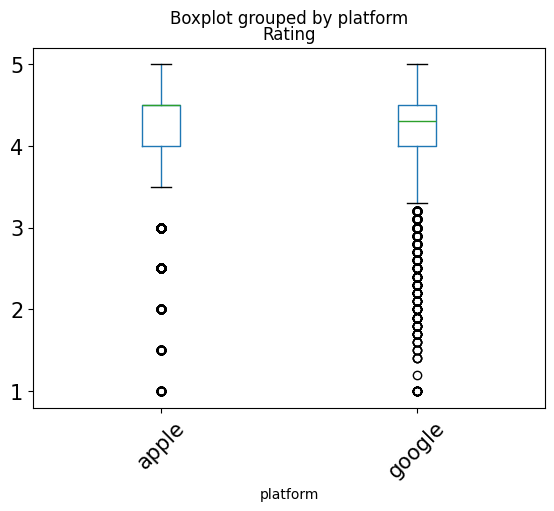

In [60]:
df.boxplot(by='platform', column='Rating', grid=False, rot=45, fontsize=15)

Stage 3 - Modelling

3a. Hypothesis formulation
3b. Getting the distribution of the data

In [61]:
apple = df[df['platform'] == 'apple']['Rating']
google = df[df['platform'] == 'google']['Rating']

In [62]:
apple_normal = stats.normaltest(apple)
print(apple_normal)

NormaltestResult(statistic=np.float64(1778.9974234584017), pvalue=np.float64(0.0))


In [63]:
google_normal = stats.normaltest(google)
print(google_normal)

NormaltestResult(statistic=np.float64(3678.6157187516856), pvalue=np.float64(0.0))


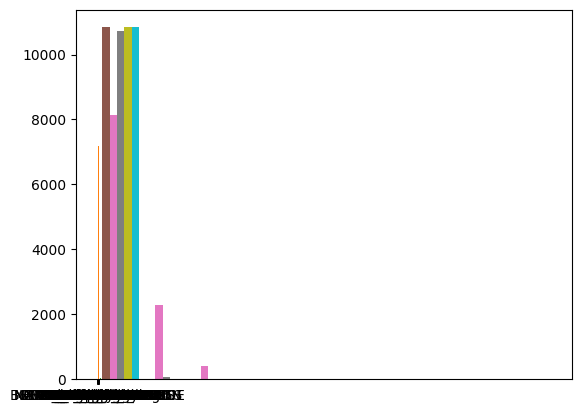

In [64]:
histoApple = plt.hist(Apple)
histoGoogle = plt.hist(Google)

In [65]:
df['Permutation1'] = np.random.permutation(df['Rating'])
df.groupby(by='platform')['Permutation1'].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
apple,6268.0,4.141321,0.612121,1.0,4.0,4.3,4.5,5.0
google,9366.0,4.130440,0.613503,1.0,4.0,4.3,4.5,5.0


In [66]:
df.groupby(by='platform')['Rating'].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
apple,6268.0,4.049697,0.726943,1.0,4.0,4.5,4.5,5.0
google,9366.0,4.191757,0.515219,1.0,4.0,4.3,4.5,5.0


In [67]:
difference = list()

for i in range(10000):
  permutation = np.random.permutation(df['Rating'])
  difference.append(np.mean(permutation[df['platform'] == 'apple']) - np.mean(permutation[df['platform'] == 'google']))

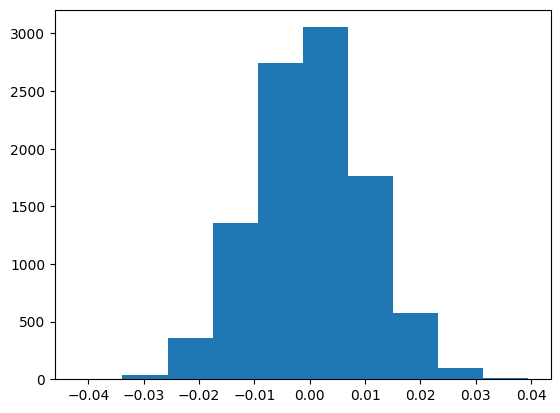

In [68]:
histo = plt.hist(difference)

In [69]:
obs_difference = np.mean(apple) - np.mean(google)
obs_difference = abs(obs_difference)
print(obs_difference)

0.1420605474512291


Stage 4 - Evaluating and concluding

4a. What is our conclusion?

In [70]:
positiveExtremes = []
negativeExtremes = []
for i in range(len(difference)):
    if (difference[i] >= obs_difference):
        positiveExtremes.append(difference[i])
    elif (difference[i] <= -obs_difference):
        negativeExtremes.append(difference[i])

print(len(positiveExtremes))
print(len(negativeExtremes))

0
0


4b. What is our decision?

4c. Other statistical tests, and next steps